In [2]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.io import loadmat

import sys
sys.path.append('..')

from src.utils_dipl import (
    train_and_evaluate,
    collect_multiple_runs,
    calculate_multiple_run_statistics,
    plot_alphas,
    plot_beta,
    print_significant_alpha,
)

import glob, os
import numpy as np


In [23]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 5070


In [3]:
fov_dir = r"C:\Users\dujme\Desktop\dipl\example particle tracking data eva\lowrange echo 10 rad_s 1perc\individual_beads_echo5"
n= len(glob.glob(os.path.join(fov_dir, "*.mat")))
b=0
for i in range(1,n-1):
    data = loadmat(fr"C:\Users\dujme\Desktop\Seminar_venv\10rad_60perc_echo5\bead_{i}.mat")
    if len(data['bsec']) == 599:
        b=b+1
    print(i,len(data['bsec']))
print('broj beadova koji ima 599 podataka:', b)

1 106
2 116
3 126
4 126
5 121
6 120
7 128
8 144
9 144
10 146
11 143
12 157
13 149
14 176
15 162
16 156
17 182
18 182
19 195
20 190
21 188
22 187
23 186
24 180
25 148
26 128
27 128
28 201
29 201
30 202
31 207
32 186
33 152
34 114
35 231
36 226
37 228
38 225
39 187
40 138
41 240
42 243
43 239
44 241
45 244
46 231
47 240
48 152
49 266
50 273
51 263
52 221
53 196
54 284
55 298
56 317
57 302
58 308
59 144
60 120
61 329
62 333
63 331
64 226
65 349
66 350
67 346
68 345
69 342
70 352
71 234
72 121
73 117
74 358
75 362
76 168
77 131
78 393
79 134
80 414
81 204
82 196
83 138
84 434
85 425
86 373
87 278
88 240
89 211
90 156
91 215
92 136
93 474
94 464
95 460
96 324
97 173
98 123
99 496
100 487
101 478
102 323
103 121
104 249
105 249
106 239
107 210
108 190
109 118
110 534
111 534
112 537
113 163
114 136
115 117
116 554
117 453
118 232
119 162
120 151
121 164
122 155
123 563
124 510
125 507
126 345
127 324
128 161
129 129
130 269
131 238
132 209
133 169
134 143
135 599
136 599
137 598
138 599
139 

In [25]:
ECHO_DIR = Path(r"C:\Users\dujme\Desktop\Seminar_venv\10rad_60perc_echo5")
N_SERIES_TO_MODEL = 10
WINDOW_SIZE = 5
ORDER = [1, 1]
TEMPERATURE = 1.0
EPOCHS = 100

FIGURE_ROOT = Path("saved_figures") / ECHO_DIR.name
FIGURE_DIR = FIGURE_ROOT / "single_run"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DPI = 200


def save_figure(fig, file_name):
    save_path = FIGURE_DIR / file_name
    fig.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved figure: {save_path}")


In [26]:
def load_particles_full_frame(echo_dir): ###Uzima sve info za tracer čestice koje imaju info za svaki frame (599)
    files = sorted(glob.glob(os.path.join(echo_dir, "bead_*.mat")))

    particle_ids = []
    x_list = []
    y_list = []
    frame_list = []

    for file in files:
        data = loadmat(file)["bsec"][:, :5]

        if len(data) == 599:
            data = data[np.argsort(data[:, 2])]

            particle_id = int(data[0, 3])
            frames = data[:, 2].astype(int)
            x = data[:, 0]
            y = data[:, 1]

            particle_ids.append(particle_id)
            x_list.append(x)
            y_list.append(y)
            frame_list.append(frames)

    particle_ids = np.array(particle_ids, dtype=int)
    x_matrix = np.column_stack(x_list)
    y_matrix = np.column_stack(y_list)
    frames = frame_list[0]

    return frames, particle_ids, x_matrix, y_matrix


def select_compact_neighborhood(particle_ids, x_matrix, y_matrix, n_particles=N_SERIES_TO_MODEL, frame_index=0): ###Traži n najbližih susjeda (n_particles) za svaku česticu i zatim uzima skup koji ima najmanju srednju vrijednost udaljenosti (najkompaktniji)
    positions = np.column_stack([x_matrix[frame_index], y_matrix[frame_index]])

    diff = positions[:, None, :] - positions[None, :, :]
    dist = np.sqrt((diff ** 2).sum(axis=2))

    order = np.argsort(dist, axis=1)
    candidate_idx = order[:, :n_particles]
    candidate_dist = np.take_along_axis(dist, candidate_idx, axis=1)

    scores = candidate_dist[:, 1:].mean(axis=1)
    best_center_idx = np.argmin(scores)

    selected_idx = candidate_idx[best_center_idx]
    selected_ids = particle_ids[selected_idx]

    result = {
        "center_particle_id": int(particle_ids[best_center_idx]),
        "selected_particle_ids": selected_ids,
        "selected_indices": selected_idx,
        "score": float(scores[best_center_idx]),
        "x_selected": x_matrix[:, selected_idx],
        "y_selected": y_matrix[:, selected_idx],
        "x0": positions[selected_idx, 0],
        "y0": positions[selected_idx, 1],
    }
    return result


frames, particle_ids, x_full, y_full = load_particles_full_frame(ECHO_DIR)

selection = select_compact_neighborhood(
    particle_ids=particle_ids,
    x_matrix=x_full,
    y_matrix=y_full,
    n_particles=N_SERIES_TO_MODEL,
    frame_index=0
)

print("Odabrane čestice:", selection["selected_particle_ids"])

print("Center particle ID:", selection["center_particle_id"])
print("Compactness score:", selection["score"])
print("x_selected shape:", selection["x_selected"].shape)
print("y_selected shape:", selection["y_selected"].shape)

Odabrane čestice: [173 175 179 165 178 181 183 158 157 156]
Center particle ID: 173
Compactness score: 18.05488583140943
x_selected shape: (599, 10)
y_selected shape: (599, 10)


In [27]:
"""

plt.figure(figsize=(7, 7))
plt.scatter(x_full[0], y_full[0], s=12, alpha=0.35, label="Sve čestive")
plt.scatter(selection["x0"], selection["y0"], s=45, label=f"{N_SERIES_TO_MODEL} najkompaktnijih")
plt.scatter(
    x_full[0, np.where(particle_ids == selection["center_particle_id"])[0][0]],
    y_full[0, np.where(particle_ids == selection["center_particle_id"])[0][0]],
    s=90,
    marker="x",
    label="''Centar'' čestica"
)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Najkompaktniji skup od {N_SERIES_TO_MODEL} tracer čestica")
plt.legend()
#plt.grid(True)
plt.axis("equal")
plt.show()
"""

"""

x_selected = selection["x_selected"]
y_selected = selection["y_selected"]
selected_ids = selection["selected_particle_ids"]

plt.figure(figsize=(7, 7))

for i in range(x_selected.shape[1]):
    plt.plot(x_selected[:, i], y_selected[:, i], lw=1, label=f"Particle {selected_ids[i]}")
    #plt.scatter(x_selected[0, i], y_selected[0, i], s=40, marker="o")
    #plt.scatter(x_selected[-1, i], y_selected[-1, i], s=40, marker="x")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Tracing {N_SERIES_TO_MODEL} čestica gledano lokalno")
#plt.grid(True)
plt.axis("equal")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
"""

"""
x_selected = selection["x_selected"]
y_selected = selection["y_selected"]
selected_ids = selection["selected_particle_ids"]

plt.figure(figsize=(7, 7))
plt.scatter(x_full[0], y_full[0], s=10, alpha=0.2)

for i in range(x_selected.shape[1]):
    plt.plot(x_selected[:, i], y_selected[:, i], lw=1)
    #plt.scatter(x_selected[0, i], y_selected[0, i], s=40, marker="o")
    #plt.scatter(x_selected[-1, i], y_selected[-1, i], s=40, marker="x")
    #plt.text(x_selected[0, i], y_selected[0, i], str(selected_ids[i]), fontsize=9)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Tracing {N_SERIES_TO_MODEL} čestica gledano globalno")
#plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()
"""

'\nx_selected = selection["x_selected"]\ny_selected = selection["y_selected"]\nselected_ids = selection["selected_particle_ids"]\n\nplt.figure(figsize=(7, 7))\nplt.scatter(x_full[0], y_full[0], s=10, alpha=0.2)\n\nfor i in range(x_selected.shape[1]):\n    plt.plot(x_selected[:, i], y_selected[:, i], lw=1)\n    #plt.scatter(x_selected[0, i], y_selected[0, i], s=40, marker="o")\n    #plt.scatter(x_selected[-1, i], y_selected[-1, i], s=40, marker="x")\n    #plt.text(x_selected[0, i], y_selected[0, i], str(selected_ids[i]), fontsize=9)\n\nplt.xlabel("x")\nplt.ylabel("y")\nplt.title(f"Tracing {N_SERIES_TO_MODEL} čestica gledano globalno")\n#plt.grid(True)\nplt.axis("equal")\nplt.tight_layout()\nplt.show()\n'

Saved figure: saved_figures\10rad_60perc_echo5\single_run\01_particle_selection_overview.png


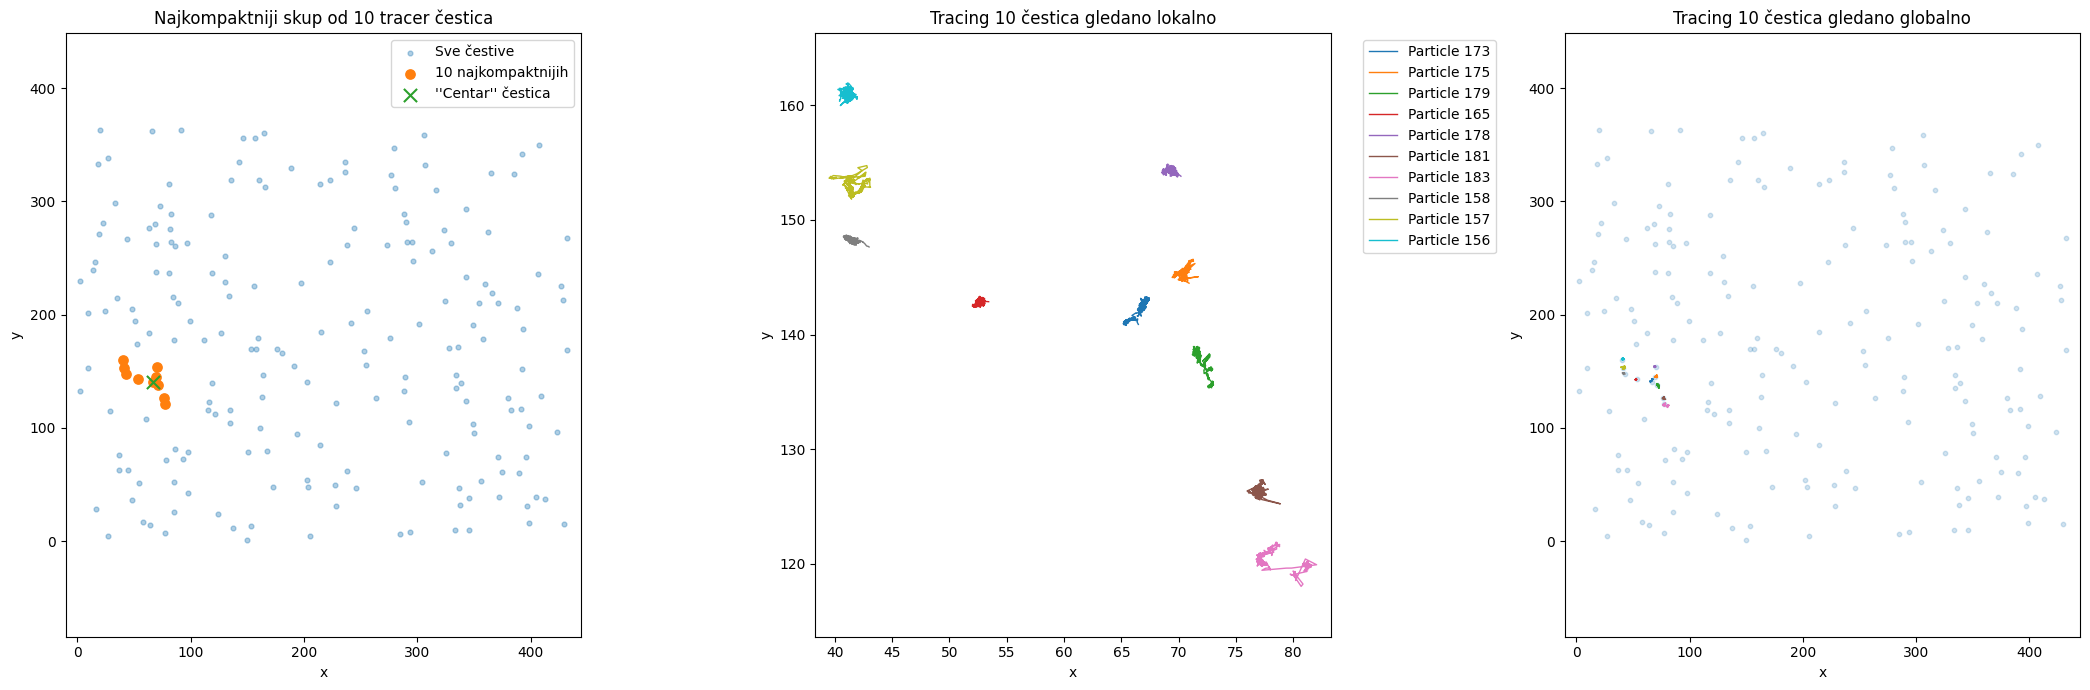

In [28]:
x_selected = selection["x_selected"]
y_selected = selection["y_selected"]
selected_ids = selection["selected_particle_ids"]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# -------------------- 1) Najkompaktniji skup --------------------
axes[0].scatter(x_full[0], y_full[0], s=12, alpha=0.35, label="Sve čestive")
axes[0].scatter(selection["x0"], selection["y0"], s=45, label=f"{N_SERIES_TO_MODEL} najkompaktnijih")
axes[0].scatter(
    x_full[0, np.where(particle_ids == selection["center_particle_id"])[0][0]],
    y_full[0, np.where(particle_ids == selection["center_particle_id"])[0][0]],
    s=90,
    marker="x",
    label="''Centar'' čestica"
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title(f"Najkompaktniji skup od {N_SERIES_TO_MODEL} tracer čestica")
axes[0].legend()
axes[0].axis("equal")

# -------------------- 2) Tracing lokalno --------------------
for i in range(x_selected.shape[1]):
    axes[1].plot(x_selected[:, i], y_selected[:, i], lw=1, label=f"Particle {selected_ids[i]}")

axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title(f"Tracing {N_SERIES_TO_MODEL} čestica gledano lokalno")
axes[1].axis("equal")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# -------------------- 3) Tracing globalno --------------------
axes[2].scatter(x_full[0], y_full[0], s=10, alpha=0.2)

for i in range(x_selected.shape[1]):
    axes[2].plot(x_selected[:, i], y_selected[:, i], lw=1)

axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_title(f"Tracing {N_SERIES_TO_MODEL} čestica gledano globalno")
axes[2].axis("equal")

plt.tight_layout()
save_figure(fig, "01_particle_selection_overview.png")
plt.show()

In [29]:
"""
y_selected = selection["y_selected"]
selected_ids = selection["selected_particle_ids"]

plt.figure(figsize=(12, 5))

for i in range(y_selected.shape[1]):
    plt.plot(frames, y_selected[:, i], lw=1.5, label=f"čestica {selected_ids[i]}")

plt.xlabel("Frame")
plt.ylabel("y")
plt.title(f"y(t) za {N_SERIES_TO_MODEL} tracer čestica")
#plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
"""

"""
y_selected = selection["y_selected"]
selected_ids = selection["selected_particle_ids"]

y_rel = y_selected - y_selected[0:1, :]

plt.figure(figsize=(12, 5))

for i in range(y_rel.shape[1]):
    plt.plot(frames, y_rel[:, i], lw=1.5, label=f"čestica {selected_ids[i]}")
    

plt.xlabel("Frame")
plt.ylabel("y - y0")
plt.title(f"y(t) - y0 za {N_SERIES_TO_MODEL} tracer čestica")
#plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
"""

"""
y_selected = selection["y_selected"]
selected_ids = selection["selected_particle_ids"]

dy = np.diff(y_selected, axis=0)
frames_dy = frames[1:]

plt.figure(figsize=(12, 5))

for i in range(dy.shape[1]):
    plt.plot(frames_dy, dy[:, i], lw=1.2, label=f"čestica {selected_ids[i]}")

plt.xlabel("Frame")
plt.ylabel("Δy = y(t) - y(t-1)")
plt.title(f"Frame-to-frame Δy za {N_SERIES_TO_MODEL} tracer čestica")
#plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
"""

'\ny_selected = selection["y_selected"]\nselected_ids = selection["selected_particle_ids"]\n\ndy = np.diff(y_selected, axis=0)\nframes_dy = frames[1:]\n\nplt.figure(figsize=(12, 5))\n\nfor i in range(dy.shape[1]):\n    plt.plot(frames_dy, dy[:, i], lw=1.2, label=f"čestica {selected_ids[i]}")\n\nplt.xlabel("Frame")\nplt.ylabel("Δy = y(t) - y(t-1)")\nplt.title(f"Frame-to-frame Δy za {N_SERIES_TO_MODEL} tracer čestica")\n#plt.grid(True)\nplt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")\nplt.tight_layout()\nplt.show()\n'

Saved figure: saved_figures\10rad_60perc_echo5\single_run\02_y_direction_overview.png


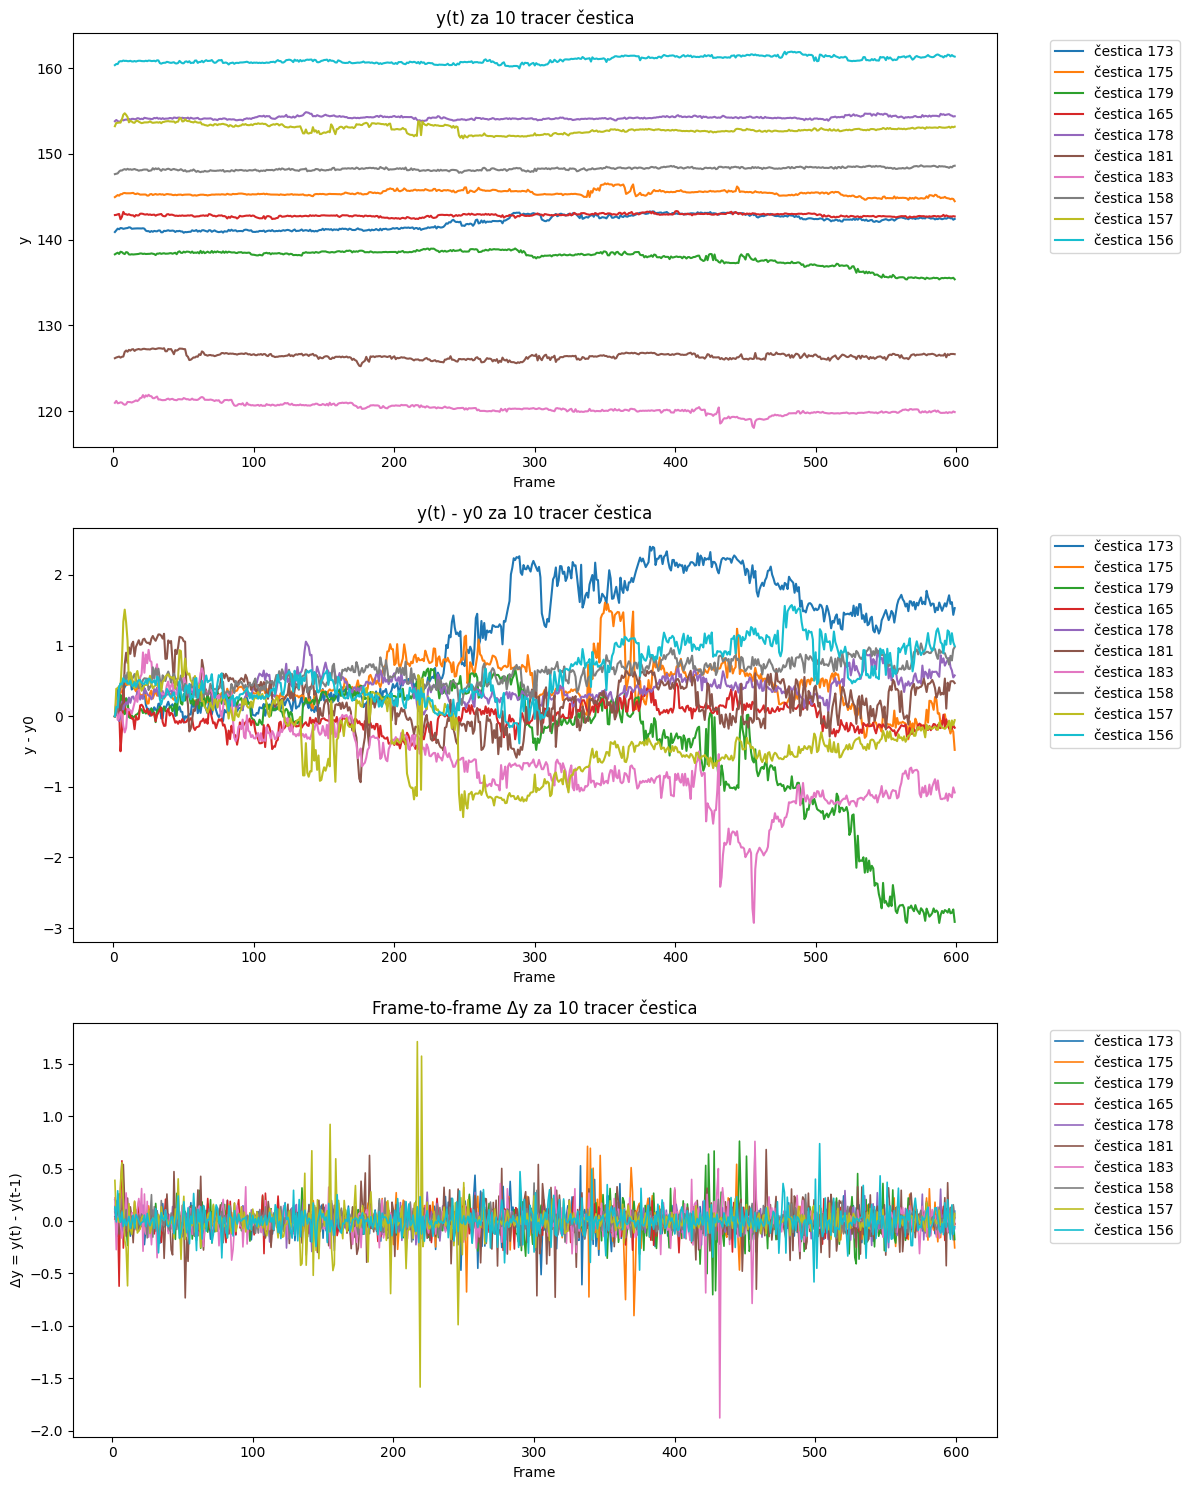

In [30]:
y_selected = selection["y_selected"]
selected_ids = selection["selected_particle_ids"]

y_rel = y_selected - y_selected[0:1, :]
dy = np.diff(y_selected, axis=0)
frames_dy = frames[1:]

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# -------------------- 1) y(t) --------------------
for i in range(y_selected.shape[1]):
    axes[0].plot(frames, y_selected[:, i], lw=1.5, label=f"čestica {selected_ids[i]}")

axes[0].set_xlabel("Frame")
axes[0].set_ylabel("y")
axes[0].set_title(f"y(t) za {N_SERIES_TO_MODEL} tracer čestica")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# -------------------- 2) y(t) - y0 --------------------
for i in range(y_rel.shape[1]):
    axes[1].plot(frames, y_rel[:, i], lw=1.5, label=f"čestica {selected_ids[i]}")

axes[1].set_xlabel("Frame")
axes[1].set_ylabel("y - y0")
axes[1].set_title(f"y(t) - y0 za {N_SERIES_TO_MODEL} tracer čestica")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# -------------------- 3) Δy --------------------
for i in range(dy.shape[1]):
    axes[2].plot(frames_dy, dy[:, i], lw=1.2, label=f"čestica {selected_ids[i]}")

axes[2].set_xlabel("Frame")
axes[2].set_ylabel("Δy = y(t) - y(t-1)")
axes[2].set_title(f"Frame-to-frame Δy za {N_SERIES_TO_MODEL} tracer čestica")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
save_figure(fig, "02_y_direction_overview.png")
plt.show()

In [31]:
def build_dcits_input(x_block, y_block, frames, mode="raw_xy"):
    if mode == "raw_xy":
        x_part = x_block
        y_part = y_block
        frames_used = frames

    elif mode == "rel_xy":
        x_part = x_block - x_block[0:1, :]
        y_part = y_block - y_block[0:1, :]
        frames_used = frames

    elif mode == "dxy":
        x_part = np.diff(x_block, axis=0)
        y_part = np.diff(y_block, axis=0)
        frames_used = frames[1:]

    data = np.concatenate([x_part, y_part], axis=1).T

    time_series = torch.tensor(data, dtype=torch.float32)
    return time_series, frames_used

variants = {
    "raw_xy": build_dcits_input(x_selected, y_selected, frames, mode="raw_xy"),
    "rel_xy": build_dcits_input(x_selected, y_selected, frames, mode="rel_xy"),
    "dxy": build_dcits_input(x_selected, y_selected, frames, mode="dxy"),
}

"""
x_part = x_block
y_part = y_block
frames_used = frames
data = np.concatenate([x_part, y_part], axis=1).T
time_series_raw = torch.tensor(data, dtype=torch.float32)

x_part = x_block - x_block[0:1, :]
y_part = y_block - y_block[0:1, :]
frames_used = frames
data = np.concatenate([x_part, y_part], axis=1).T
time_series_rel = torch.tensor(data, dtype=torch.float32)

x_part = np.diff(x_block, axis=0)
y_part = np.diff(y_block, axis=0)
frames_used = frames[1:]
data = np.concatenate([x_part, y_part], axis=1).T
time_series_diff = torch.tensor(data, dtype=torch.float32)
"""

def run_single_dcits(time_series, name):
    train_config = {
        "verbose": True,
        "device": device,
        "seed": seed,
        "learning_rate": 1e-3,
        "scheduler_patience": 5,
        "early_stopping_modifier": 2,
        "criterion": nn.MSELoss(),
        "epochs": 200,
        "batch_size": 64,
        "train_ratio": 0.8,
        "val_ratio": 0.1,
    }

    (
        test_loss,
        train_losses,
        val_losses,
        split_results,
        debug_info,
        model,
    ) = train_and_evaluate(
        time_series=time_series,
        window_size=WINDOW_SIZE,
        temperature=TEMPERATURE,
        order=ORDER,
        config=train_config,
    )

    train_split = split_results["train"]
    val_split = split_results["val"]
    test_split = split_results["test"]

    return {
        "name": name,
        "test_loss": test_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "split_results": split_results,
        "train_split": train_split,
        "val_split": val_split,
        "test_split": test_split,
        "train_loss_eval": train_split["loss"],
        "val_loss_eval": val_split["loss"],
        "test_loss_eval": test_split["loss"],
        "f_train": train_split["focus"],
        "c_train": train_split["coefficients"],
        "alpha_mean_train": train_split["alpha_mean"],
        "alpha_std_train": train_split["alpha_std"],
        "alpha_bias_train": train_split["alpha_bias"],
        "alpha_bias_std_train": train_split["alpha_bias_std"],
        "train_inputs": train_split["inputs"],
        "train_targets": train_split["targets"],
        "f_val": val_split["focus"],
        "c_val": val_split["coefficients"],
        "alpha_mean_val": val_split["alpha_mean"],
        "alpha_std_val": val_split["alpha_std"],
        "alpha_bias_val": val_split["alpha_bias"],
        "alpha_bias_std_val": val_split["alpha_bias_std"],
        "val_inputs": val_split["inputs"],
        "val_targets": val_split["targets"],
        "f_test": test_split["focus"],
        "c_test": test_split["coefficients"],
        "alpha_mean": test_split["alpha_mean"],
        "alpha_std": test_split["alpha_std"],
        "alpha_bias": test_split["alpha_bias"],
        "alpha_bias_std": test_split["alpha_bias_std"],
        "test_inputs": test_split["inputs"],
        "test_targets": test_split["targets"],
        "debug_info": debug_info,
        "model": model,
    }


In [32]:
time_series_, frames = variants['raw_xy'] #Prvo svi x-evi, onda svi y-oni
print(time_series_[10:]) #y-oni
print(time_series_[:10]) #x-oni

tensor([[140.8843, 141.0875, 141.2774,  ..., 142.4991, 142.3199, 142.4149],
        [144.9557, 145.0718, 145.1946,  ..., 144.7793, 144.7347, 144.4795],
        [138.2793, 138.3844, 138.4667,  ..., 135.4967, 135.5437, 135.3678],
        ...,
        [147.6370, 147.6789, 147.7258,  ..., 148.4266, 148.5829, 148.6166],
        [153.2284, 153.6167, 153.6249,  ..., 153.1686, 153.1006, 153.1728],
        [160.3537, 160.4867, 160.4792,  ..., 161.5289, 161.4014, 161.3480]])
tensor([[66.4806, 66.3759, 66.4129,  ..., 66.9045, 66.8769, 67.0095],
        [69.6257, 69.7458, 69.6441,  ..., 70.4408, 70.4326, 70.9044],
        [71.2064, 71.3313, 71.3600,  ..., 72.6525, 72.5897, 72.6874],
        ...,
        [42.9911, 42.9425, 42.7762,  ..., 41.0946, 41.0685, 41.1665],
        [41.4344, 41.3768, 41.4420,  ..., 41.0048, 41.1607, 41.1063],
        [40.4214, 40.4247, 40.4863,  ..., 40.7566, 40.8060, 40.8058]])


In [33]:
#korisno kasnije za plotanje
labels_raw = [f"x_{pid}" for pid in selected_ids] + [f"y_{pid}" for pid in selected_ids]
labels_rel = [f"xrel_{pid}" for pid in selected_ids] + [f"yrel_{pid}" for pid in selected_ids]
labels_dxy = [f"dx_{pid}" for pid in selected_ids] + [f"dy_{pid}" for pid in selected_ids]

labels_raw

['x_173',
 'x_175',
 'x_179',
 'x_165',
 'x_178',
 'x_181',
 'x_183',
 'x_158',
 'x_157',
 'x_156',
 'y_173',
 'y_175',
 'y_179',
 'y_165',
 'y_178',
 'y_181',
 'y_183',
 'y_158',
 'y_157',
 'y_156']

In [34]:
label_map = {
    "raw_xy": labels_raw,
    "rel_xy": labels_rel,
    "dxy": labels_dxy,
}

all_results = {}

for variant_name, (time_series, frames_used) in variants.items():
    print("=" * 80)
    print(f"Running variant: {variant_name}")
    print("time_series shape [N, T]:", tuple(time_series.shape))

    result = run_single_dcits(time_series, variant_name)

    all_results[variant_name] = {
        "result": result,
        "frames_used": frames_used,
        "time_series": time_series,
    }

    print(f"Final test loss ({variant_name}): {result['test_loss']:.6f}")

Running variant: raw_xy
time_series shape [N, T]: (20, 599)
Epoch 1/200, Train Loss: 4.617994e+05, Val Loss: 1.092901e+05, LR: 1.00e-03
Epoch 2/200, Train Loss: 4.525305e+04, Val Loss: 9.530457e+03, LR: 1.00e-03
Epoch 3/200, Train Loss: 1.058560e+04, Val Loss: 4.788116e+03, LR: 1.00e-03
Epoch 4/200, Train Loss: 3.017121e+03, Val Loss: 1.109546e+03, LR: 1.00e-03
Epoch 5/200, Train Loss: 1.100085e+03, Val Loss: 8.423613e+02, LR: 1.00e-03
Epoch 6/200, Train Loss: 6.242767e+02, Val Loss: 4.783626e+02, LR: 1.00e-03
Epoch 7/200, Train Loss: 3.356767e+02, Val Loss: 1.287967e+02, LR: 1.00e-03
Epoch 8/200, Train Loss: 1.146389e+02, Val Loss: 1.088448e+02, LR: 1.00e-03
Epoch 9/200, Train Loss: 4.930468e+01, Val Loss: 4.209589e+01, LR: 1.00e-03
Epoch 10/200, Train Loss: 2.690733e+01, Val Loss: 1.060276e+01, LR: 1.00e-03
Epoch 11/200, Train Loss: 8.597272e+00, Val Loss: 7.149095e+00, LR: 1.00e-03
Epoch 12/200, Train Loss: 4.267007e+00, Val Loss: 5.418321e+00, LR: 1.00e-03
Epoch 13/200, Train Loss:

Saved figure: saved_figures\10rad_60perc_echo5\single_run\03_loss_curves.png


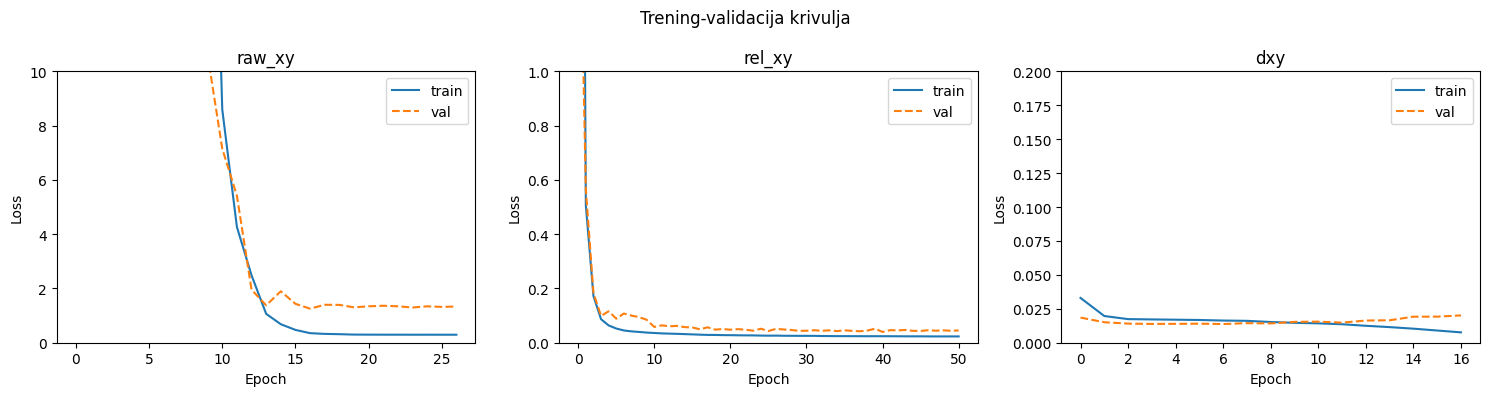

Test losses:
raw_xy: 1.415628
rel_xy: 0.065583
dxy: 0.014412


In [35]:
fig, axes = plt.subplots(1, len(all_results), figsize=(15, 4))

for ax, (variant_name, bundle) in zip(axes, all_results.items()):
    ax.plot(bundle["result"]["train_losses"], label="train")
    ax.plot(bundle["result"]["val_losses"], linestyle="--", label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(variant_name)
    ax.legend()

axes[0].set_ylim(0, 10)    
axes[1].set_ylim(0, 1)    
axes[2].set_ylim(0, 0.2)   

fig.suptitle("Trening-validacija krivulja")
plt.tight_layout()
save_figure(fig, "03_loss_curves.png")
plt.show()

print("Test losses:")
for variant_name, bundle in all_results.items():
    print(f"{variant_name}: {bundle['result']['test_loss']:.6f}")

In [36]:
"""
ALPHA_PLOT_FIGSIZE = (18, 10)
ALPHA_PLOT_FONT_SIZE = 9
ALPHA_TEXT_THRESHOLD = 0.12

for variant_name, bundle in all_results.items():
    alpha = bundle["result"]["alpha_mean"][1].copy()
    alpha[np.abs(alpha) < ALPHA_TEXT_THRESHOLD] = 0.0

    alpha_placeholder = torch.zeros_like(torch.tensor(alpha, dtype=torch.float32))

    print("=" * 80)
    print(f"Variant: {variant_name}")
    plot_alphas(
        alpha,
        alpha_placeholder,
        title=rf"\alpha ({variant_name})",
        figsize=ALPHA_PLOT_FIGSIZE,
        font_size=ALPHA_PLOT_FONT_SIZE,
        cbar_font=10,
        space=0.25,
        force_12=True,
    )
"""

'\nALPHA_PLOT_FIGSIZE = (18, 10)\nALPHA_PLOT_FONT_SIZE = 9\nALPHA_TEXT_THRESHOLD = 0.12\n\nfor variant_name, bundle in all_results.items():\n    alpha = bundle["result"]["alpha_mean"][1].copy()\n    alpha[np.abs(alpha) < ALPHA_TEXT_THRESHOLD] = 0.0\n\n    alpha_placeholder = torch.zeros_like(torch.tensor(alpha, dtype=torch.float32))\n\n    print("=" * 80)\n    print(f"Variant: {variant_name}")\n    plot_alphas(\n        alpha,\n        alpha_placeholder,\n        title=rf"\x07lpha ({variant_name})",\n        figsize=ALPHA_PLOT_FIGSIZE,\n        font_size=ALPHA_PLOT_FONT_SIZE,\n        cbar_font=10,\n        space=0.25,\n        force_12=True,\n    )\n'

Variant: raw_xy
Saved figure: saved_figures\10rad_60perc_echo5\single_run\04_alpha_heatmap_test_raw_xy.png


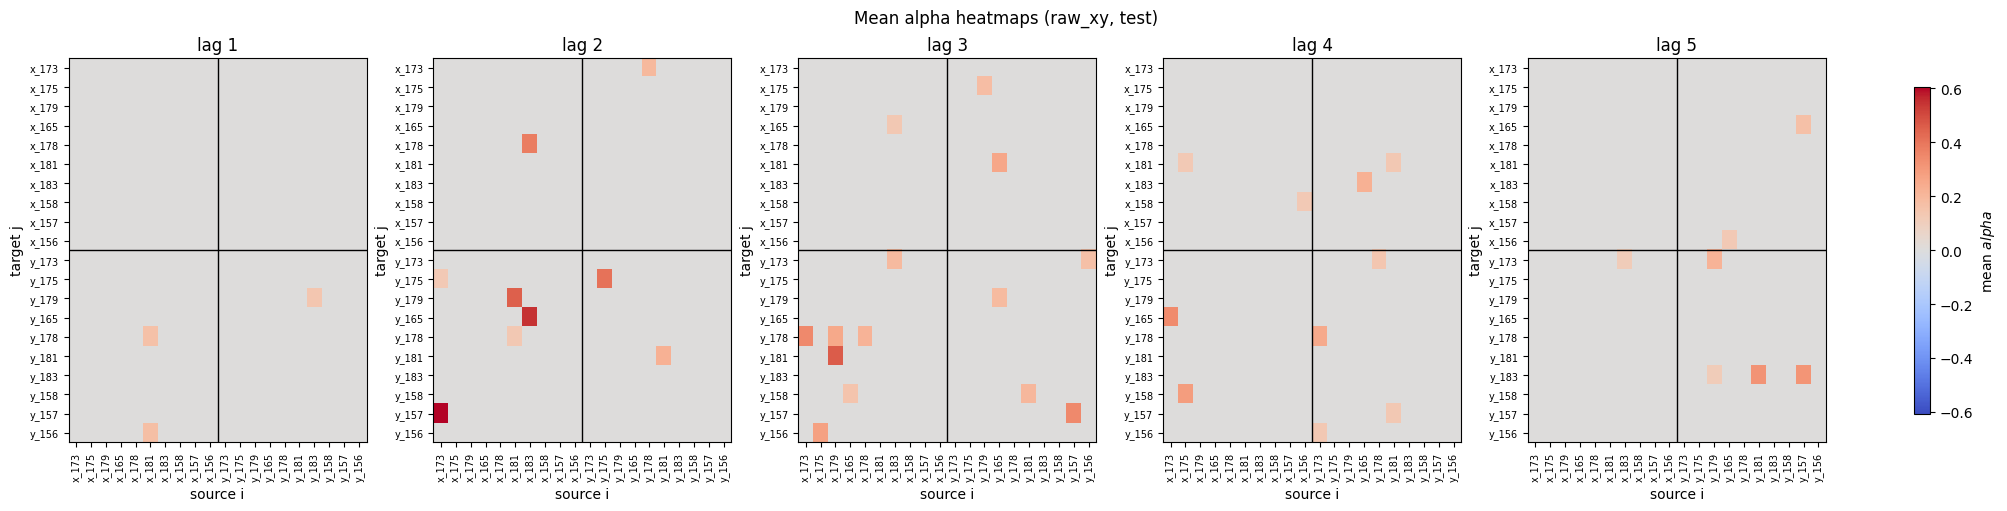

Variant: rel_xy
Saved figure: saved_figures\10rad_60perc_echo5\single_run\04_alpha_heatmap_test_rel_xy.png


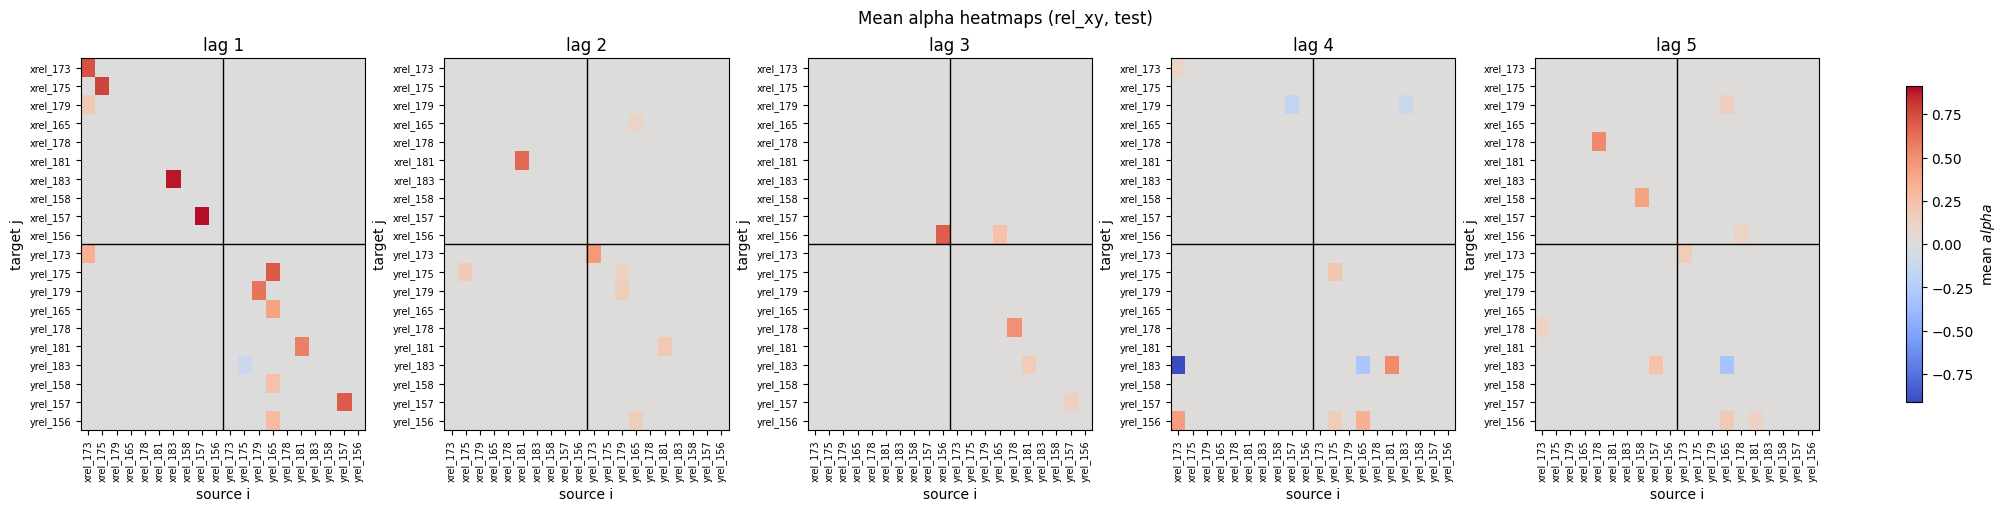

Variant: dxy
Saved figure: saved_figures\10rad_60perc_echo5\single_run\04_alpha_heatmap_test_dxy.png


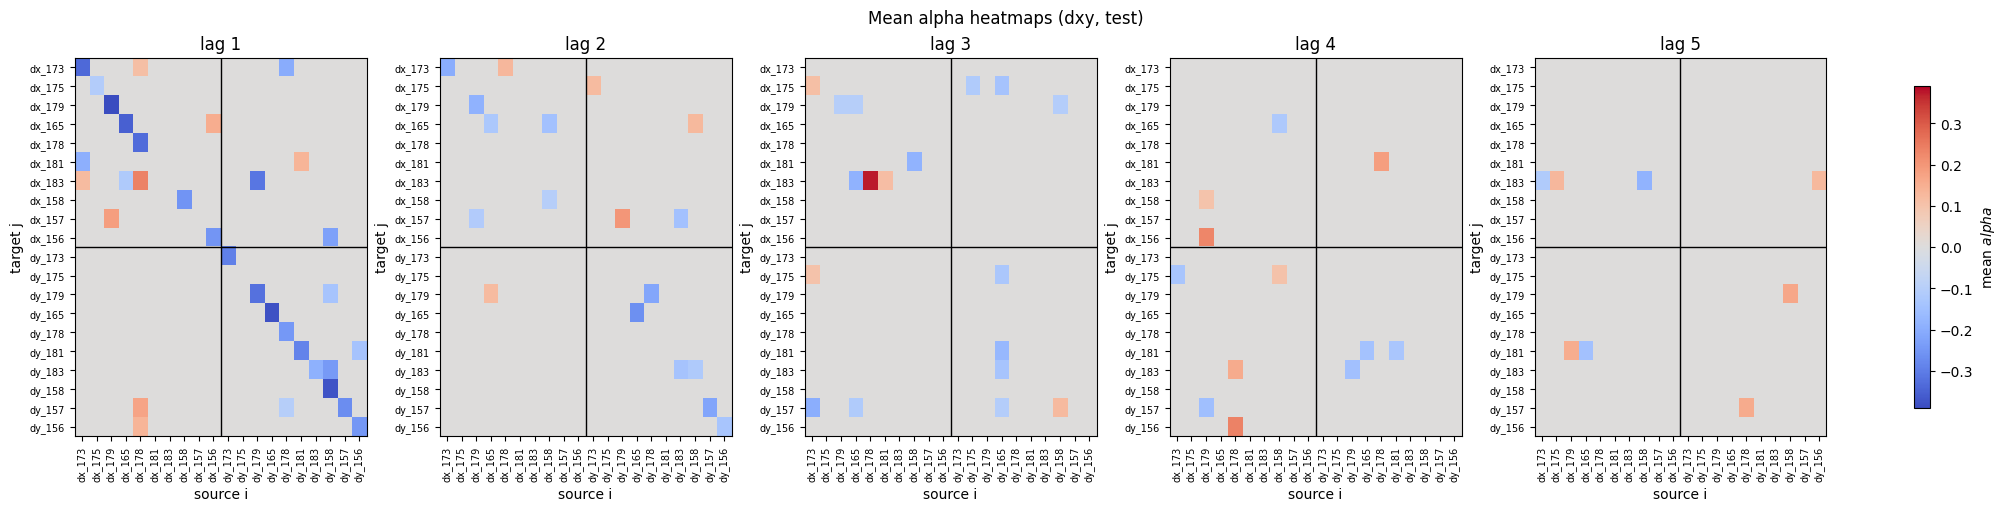

In [37]:
def plot_alpha_heatmaps(alpha_mean, labels, window_size=WINDOW_SIZE, title="", threshold=0.0, flip_lag_axis=True, cmap="coolwarm", save_name=None):
    """Plot one alpha heatmap per lag: source i on x-axis, target j on y-axis."""
    alpha_plot = np.array(alpha_mean, copy=True)

    if flip_lag_axis:
        # DCIts stores lag order reversed for plotting, so we flip only the lag axis.
        # We do not transpose: alpha[j, i, l] already means source i -> target j.
        alpha_plot = np.flip(alpha_plot, axis=2)

    if threshold > 0:
        alpha_plot[np.abs(alpha_plot) < threshold] = 0.0

    n_series = alpha_plot.shape[0]
    vmax = np.max(np.abs(alpha_plot))
    if vmax == 0:
        vmax = 1.0

    fig, axes = plt.subplots(1, window_size, figsize=(4 * window_size, 5), constrained_layout=True)
    if window_size == 1:
        axes = [axes]

    split = n_series // 2

    for lag_idx, ax in enumerate(axes):
        matrix = alpha_plot[:, :, lag_idx]
        im = ax.imshow(matrix, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_title(f"lag {lag_idx + 1}")
        ax.set_xlabel("source i")
        ax.set_ylabel("target j")
        ax.set_xticks(range(n_series))
        ax.set_yticks(range(n_series))
        ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)

        if split < n_series:
            ax.axvline(split - 0.5, color="black", linewidth=1)
            ax.axhline(split - 0.5, color="black", linewidth=1)

    fig.suptitle(title)
    fig.colorbar(im, ax=axes, shrink=0.85, label=r"mean $alpha$")
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


ALPHA_HEATMAP_THRESHOLD = 0.1

for variant_name, bundle in all_results.items():
    print("=" * 80)
    print(f"Variant: {variant_name}")

    alpha_mean_test = bundle["result"]["alpha_mean"][1]
    labels = label_map[variant_name]

    plot_alpha_heatmaps(
        alpha_mean=alpha_mean_test,
        labels=labels,
        window_size=WINDOW_SIZE,
        title=f"Mean alpha heatmaps ({variant_name}, test)",
        threshold=ALPHA_HEATMAP_THRESHOLD,
        flip_lag_axis=True,
        save_name=f"04_alpha_heatmap_test_{variant_name}.png",
    )

# Train split is now available directly too, for example:
# plot_alpha_heatmaps(
#     alpha_mean=all_results["raw_xy"]["result"]["alpha_mean_train"][1],
#     labels=label_map["raw_xy"],
#     window_size=WINDOW_SIZE,
#     title="Mean alpha heatmaps (raw_xy, train)",
#     threshold=ALPHA_HEATMAP_THRESHOLD,
#     flip_lag_axis=True,
# )


Variant: raw_xy
Saved figure: saved_figures\10rad_60perc_echo5\single_run\05_alpha_heatmap_train_raw_xy.png


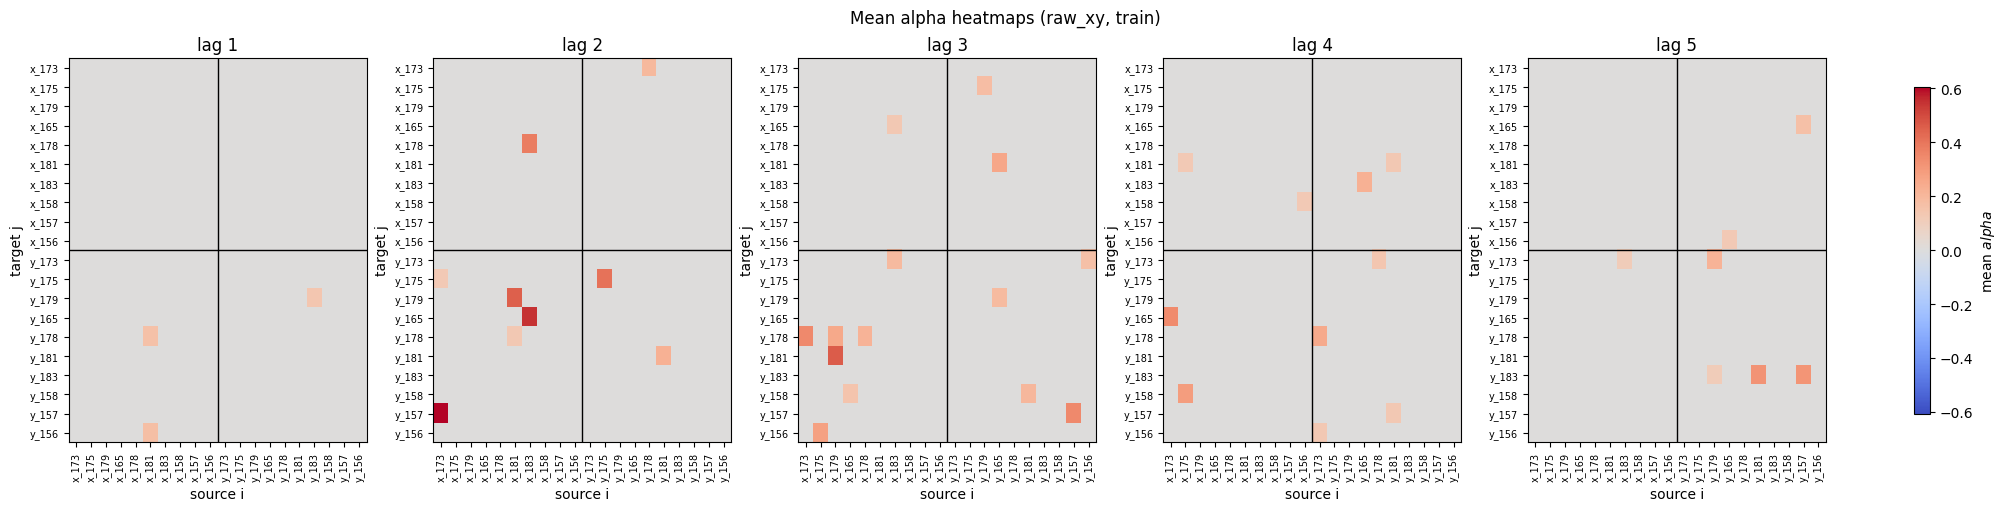

Variant: rel_xy
Saved figure: saved_figures\10rad_60perc_echo5\single_run\05_alpha_heatmap_train_rel_xy.png


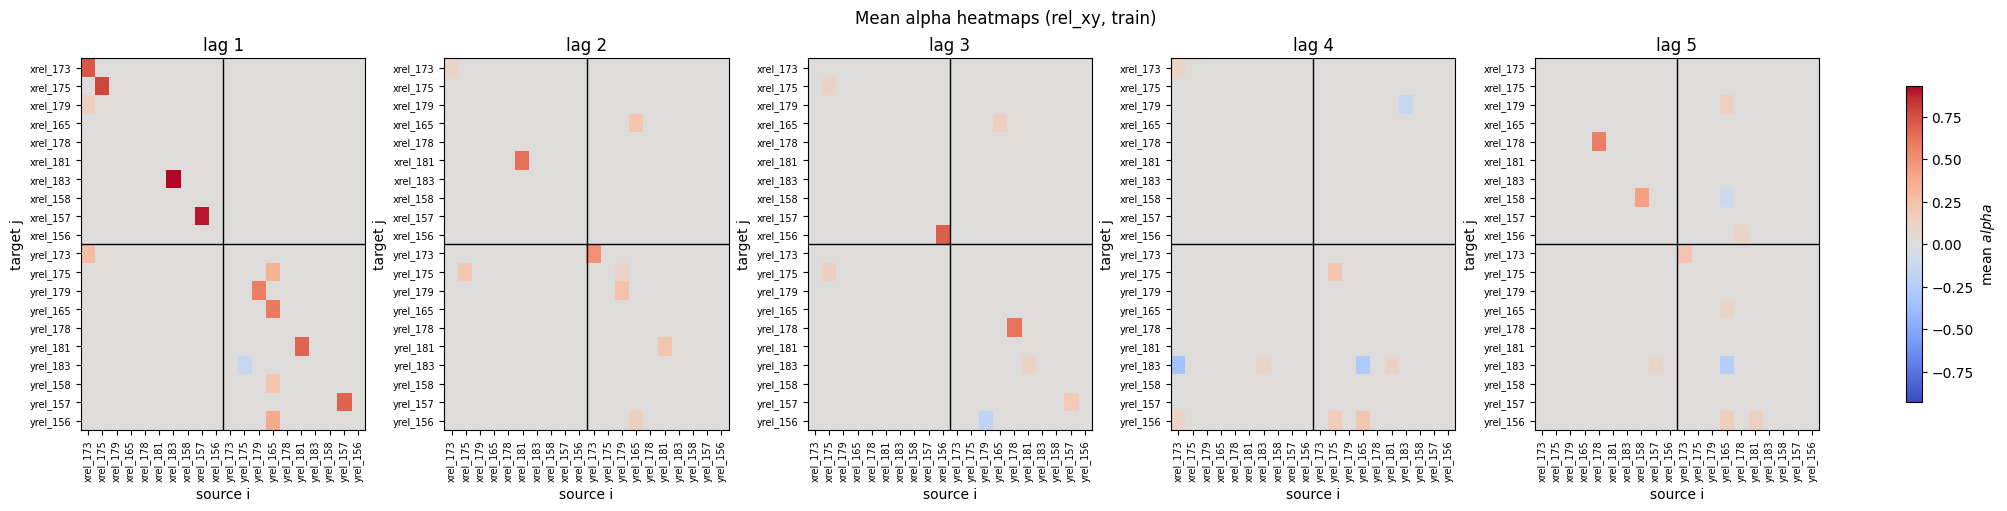

Variant: dxy
Saved figure: saved_figures\10rad_60perc_echo5\single_run\05_alpha_heatmap_train_dxy.png


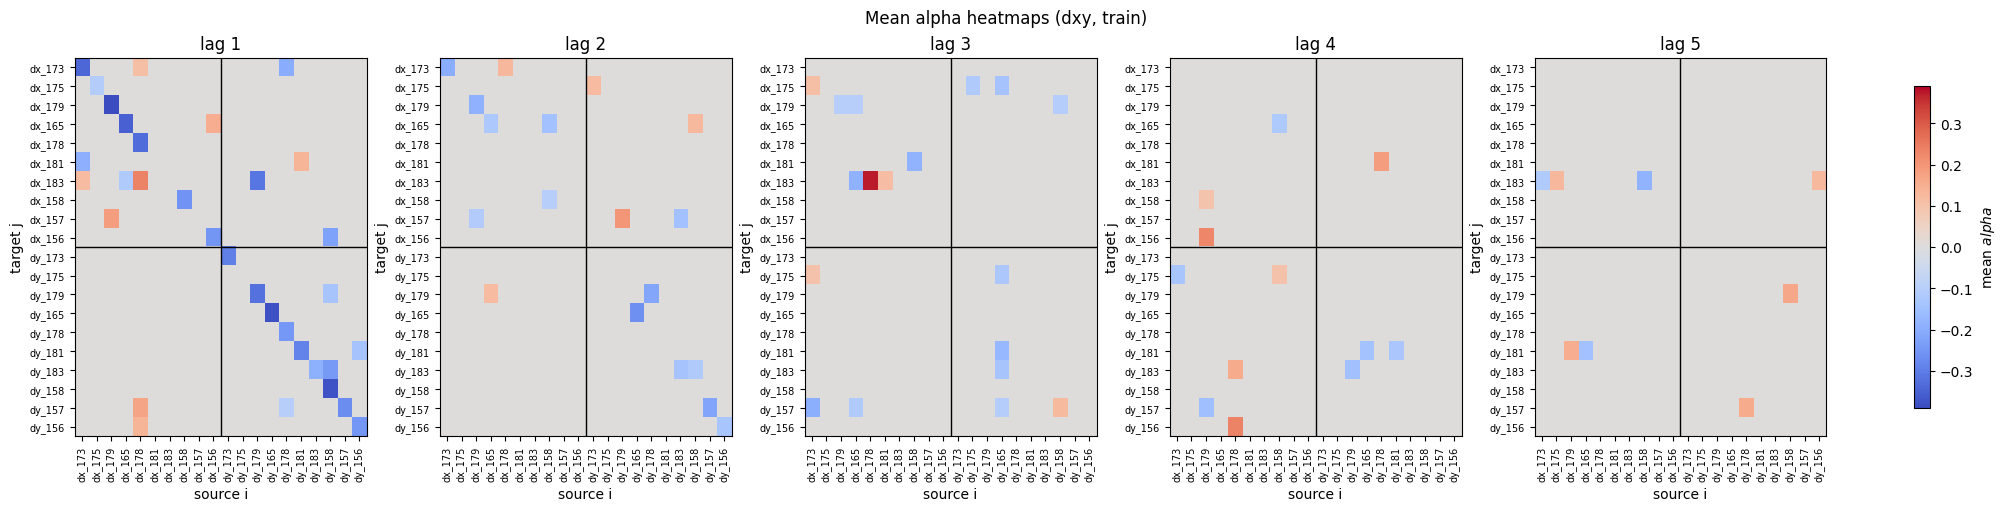

In [38]:
for variant_name, bundle in all_results.items():
    print("=" * 80)
    print(f"Variant: {variant_name}")

    plot_alpha_heatmaps(
        alpha_mean=bundle["result"]["alpha_mean_train"][1],
        labels=label_map[variant_name],
        window_size=WINDOW_SIZE,
        title=f"Mean alpha heatmaps ({variant_name}, train)",
        threshold=ALPHA_HEATMAP_THRESHOLD,
        flip_lag_axis=True,
        save_name=f"05_alpha_heatmap_train_{variant_name}.png",
    )


In [39]:
def get_alpha_seq_physical_split(all_results, variant_name, split_name="test", order_idx=1):
    result = all_results[variant_name]["result"]
    alpha_seq = result[f"f_{split_name}"][order_idx] * result[f"c_{split_name}"][order_idx] ###Racuna alphe za trazeni dataset
    # Shape: [window, target, source, lag]
    # Flip only the lag axis so physical lag 1 becomes index 0.
    return np.flip(alpha_seq, axis=3)

def get_alpha_seq_all_sets(all_results, variant_name, order_idx=1): #Vraca sve aplha vrj za svaki prozor i sve datasetove (train, val, test) te indeks od kojeg počinje test dio.
    alpha_train = get_alpha_seq_physical_split(all_results, variant_name, split_name="train", order_idx=order_idx)
    alpha_val = get_alpha_seq_physical_split(all_results, variant_name, split_name="val", order_idx=order_idx)
    alpha_test = get_alpha_seq_physical_split(all_results, variant_name, split_name="test", order_idx=order_idx)

    alpha_all = np.concatenate([alpha_train, alpha_val, alpha_test], axis=0)
    test_start = alpha_train.shape[0] + alpha_val.shape[0]
    return alpha_all, test_start


Saved figure: saved_figures\10rad_60perc_echo5\single_run\06_selected_alpha_traces.png


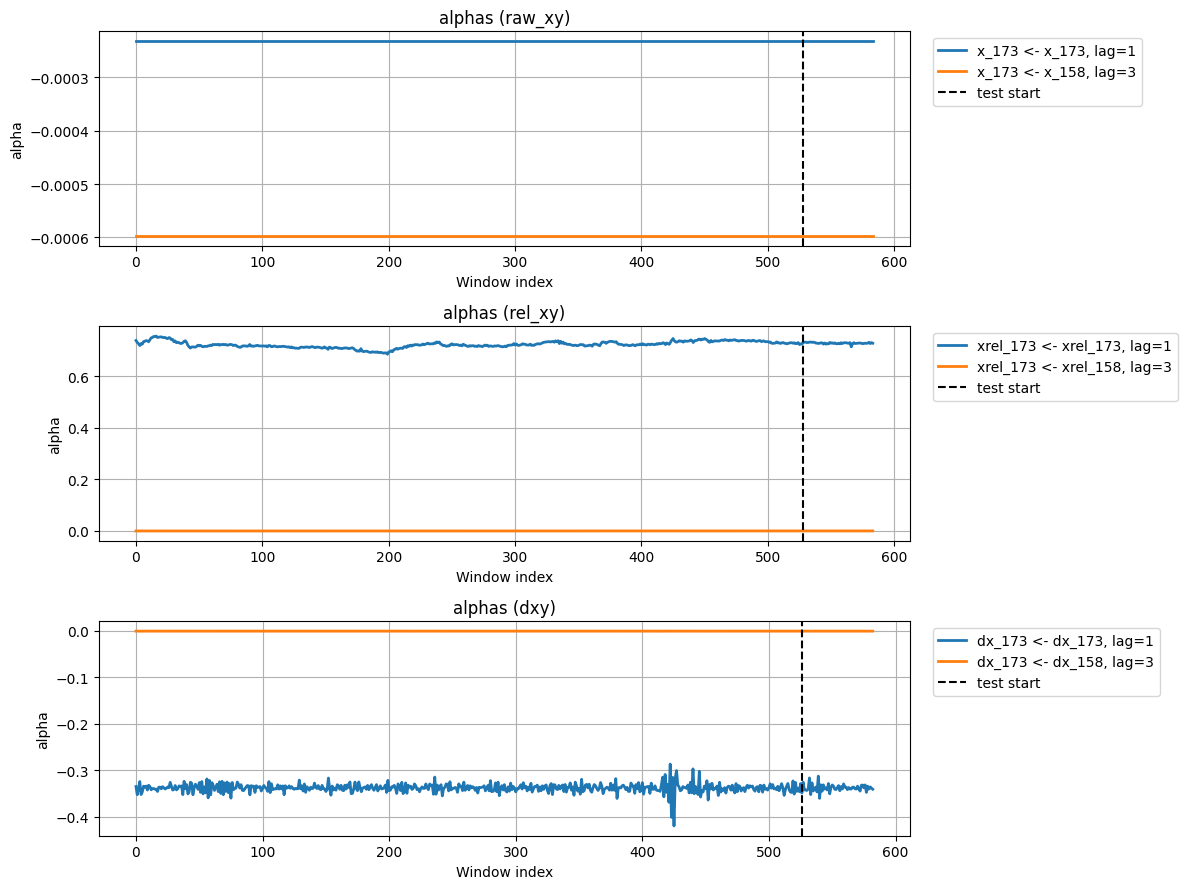

In [40]:
#Ovo je ako zelim plotati neku specificnu kombinaciju
# Each tuple is (target_idx, source_idx, lag).
selected_alphas = [
    (0, 0, 1),
    (0, 7, 3),
]

variants_to_plot = ["raw_xy", "rel_xy", "dxy"]

fig, axes = plt.subplots(len(variants_to_plot), 1, figsize=(12, 9))
if len(variants_to_plot) == 1:
    axes = [axes]

for ax, variant_name in zip(axes, variants_to_plot):
    labels = label_map[variant_name]
    alpha_all, test_start = get_alpha_seq_all_sets(all_results, variant_name, order_idx=1)

    for target_idx, source_idx, lag in selected_alphas:
        ax.plot(
            alpha_all[:, target_idx, source_idx, lag - 1],
            lw=2,
            label=f"{labels[target_idx]} <- {labels[source_idx]}, lag={lag}",
        )

    ax.axvline(test_start - 0.5, color="black", linestyle="--", lw=1.5, label="test start")
    ax.set_title(f"alphas ({variant_name})")
    ax.set_xlabel("Window index")
    ax.set_ylabel("alpha")
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
save_figure(fig, "06_selected_alpha_traces.png")
plt.show()


Saved figure: saved_figures\10rad_60perc_echo5\single_run\07_self_alpha_lag1.png


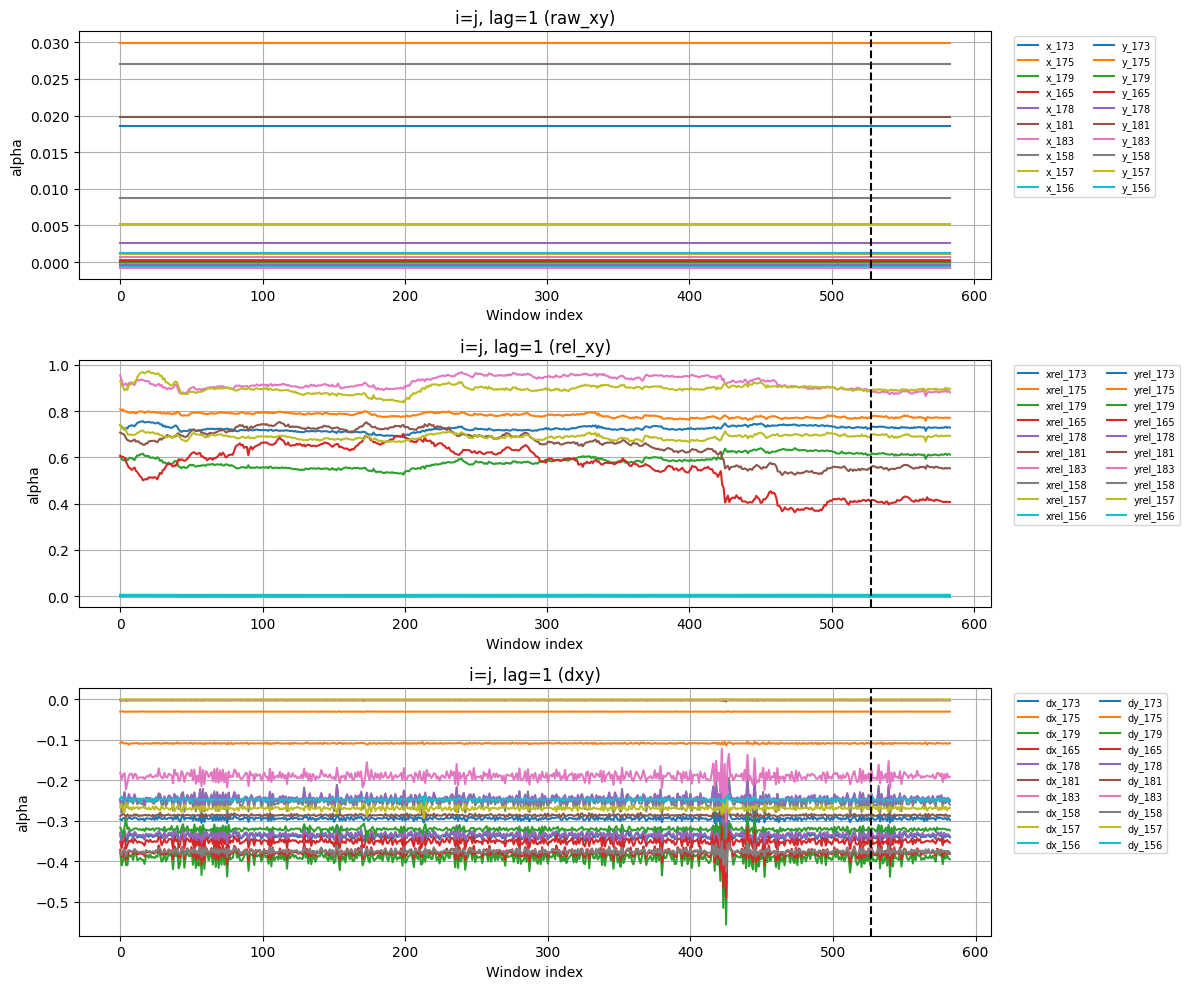

In [41]:

#Ovo plota i=j l=1

variants_to_plot = ["raw_xy", "rel_xy", "dxy"]

fig, axes = plt.subplots(len(variants_to_plot), 1, figsize=(12, 10))
if len(variants_to_plot) == 1:
    axes = [axes]

for ax, variant_name in zip(axes, variants_to_plot):
    labels = label_map[variant_name]
    alpha_all, test_start = get_alpha_seq_all_sets(all_results, variant_name, order_idx=1)
    n_series = alpha_all.shape[1]

    # After the lag flip in the helper, lag=1 is index 0.
    for series_idx in range(n_series):
        ax.plot(
            alpha_all[:, series_idx, series_idx, 0],
            lw=1.5,
            label=labels[series_idx],
        )

    ax.axvline(test_start - 0.5, color="black", linestyle="--", lw=1.5)
    ax.set_title(f"i=j, lag=1 ({variant_name})")
    ax.set_xlabel("Window index")
    ax.set_ylabel("alpha")
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)

plt.tight_layout()
save_figure(fig, "07_self_alpha_lag1.png")
plt.show()


In [42]:
order_idx = 1
split_name = "test"   
threshold = 0.1

for variant_name in ["raw_xy", "rel_xy", "dxy"]:
    print("=" * 80)
    print(f"Variant: {variant_name} ({split_name})")

    alpha_seq = (
        all_results[variant_name]["result"][f"f_{split_name}"][order_idx]
        * all_results[variant_name]["result"][f"c_{split_name}"][order_idx]
    )  # shape: [window, target, source, lag] sve alpha vrj.

    alpha_mean_tgt_src = alpha_seq.mean(axis=0)  # [target, source, lag] alpha mean vrj
    alpha_std_tgt_src = alpha_seq.std(axis=0)    # [target, source, lag] alpha std vrj

    # print_significant_alpha expects [source, target, lag]!!!!!,
    # so we swap target/source here.
    alpha_mean_src_tgt = np.transpose(alpha_mean_tgt_src, (1, 0, 2))
    alpha_std_src_tgt = np.transpose(alpha_std_tgt_src, (1, 0, 2))

    # Avoid crash when std == 0 inside print_significant_alpha.
    alpha_std_src_tgt = alpha_std_src_tgt.copy()
    alpha_std_src_tgt[alpha_std_src_tgt == 0] = 1e-12

    print_significant_alpha(
        alpha_mean_src_tgt,
        alpha_std_src_tgt,
        torch.zeros_like(torch.tensor(alpha_mean_src_tgt, dtype=torch.float32)),
        threshold=threshold,
    )

    print()

Variant: raw_xy (test)
alpha_1122 = (0.12423597 ± 0.00000008) Not in ground truth
alpha_1144 = (0.34409460 ± 0.00000003) Not in ground truth
alpha_1153 = (0.3490657 ± 0.0000001) Not in ground truth
alpha_1192 = (0.6050035 ± 0.0000004) Not in ground truth
alpha_264 = (0.12400719 ± 0.00000007) Not in ground truth
alpha_2184 = (0.2901218 ± 0.0000002) Not in ground truth
alpha_2203 = (0.2761728 ± 0.0000001) Not in ground truth
alpha_3153 = (0.2542334 ± 0.0000001) Not in ground truth
alpha_3163 = (0.4621809 ± 0.0000003) Not in ground truth
alpha_4183 = (0.14662269 ± 0.00000004) Not in ground truth
alpha_5153 = (0.21707055 ± 0.00000009) Not in ground truth
alpha_6132 = (0.4521300 ± 0.0000003) Not in ground truth
alpha_6151 = (0.16204324 ± 0.00000004) Not in ground truth
alpha_6152 = (0.13124989 ± 0.00000004) Not in ground truth
alpha_6201 = (0.17457488 ± 0.00000006) Not in ground truth
alpha_743 = (0.12910615 ± 0.00000004) Not in ground truth
alpha_752 = (0.38282448 ± 0.00000003) Not in grou